In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

In [76]:
import sys
from pathlib import Path

# Go up to project root
project_root = Path().resolve().parents[1]
sys.path.insert(0, str(project_root))

from library_testing.lauscher.audiowaves import MonoAudioWave
from library_testing.lauscher.transformations.wave2spike import Wave2Spike

In [77]:
# ============================================================
# 1️⃣ Generate Synthetic Bat FM Sweep
# ============================================================

def generate_fm_sweep(duration=0.5,
                      f_start=5_000,
                      f_end=1_000,
                      sample_rate=48_000):

    t = np.linspace(0, duration, int(sample_rate * duration))
    freqs = np.linspace(f_start, f_end, len(t))

    # Integrate frequency to phase
    phase = 2 * np.pi * np.cumsum(freqs) / sample_rate
    signal = np.sin(phase)

    # Apply smooth window (avoid click edges)
    window = np.hanning(len(signal))
    signal *= window

    return signal, sample_rate, t


waveform, sr, t = generate_fm_sweep()

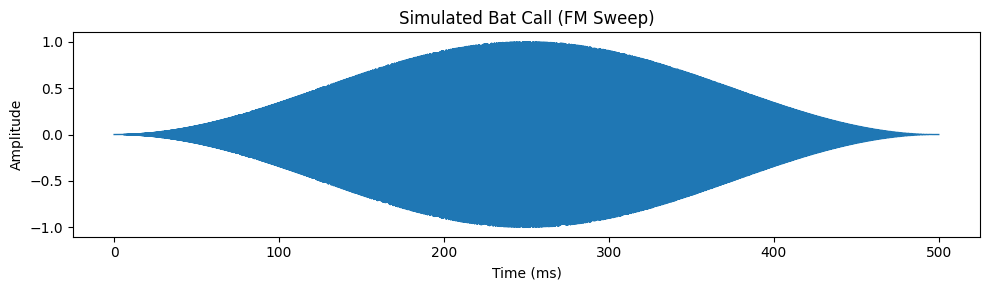

In [78]:
# ============================================================
# 2️⃣ Plot Waveform (Amplitude vs Time)
# ============================================================

plt.figure(figsize=(10, 3))
plt.plot(t * 1000, waveform, linewidth=1)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Simulated Bat Call (FM Sweep)")
plt.tight_layout()
plt.show()

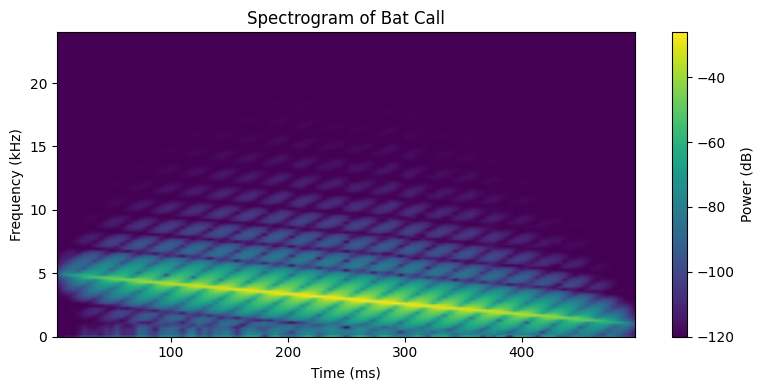

In [79]:
# ============================================================
# 3️⃣ Plot Spectrogram (Frequency vs Time)
# ============================================================

f, t_spec, Sxx = spectrogram(waveform, fs=sr)

plt.figure(figsize=(8, 4))
plt.pcolormesh(t_spec * 1000, f / 1000, 10 * np.log10(Sxx + 1e-12),
               shading='gouraud')
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (ms)")
plt.title("Spectrogram of Bat Call")
plt.colorbar(label="Power (dB)")
#plt.ylim(0, 50)  # show ultrasonic range
plt.tight_layout()
plt.show()





In [80]:
# ============================================================
# 4️⃣ Pass Through Lauscher Cochlea Model
# ============================================================

wave = MonoAudioWave(waveform, sr)
trafo = Wave2Spike(num_channels=70)

spikes = wave.transform(trafo)

# Export if you want
spikes.export("bat_spikes.npz")



In [81]:

# ============================================================
# 5️⃣ Load Spikes (2 x N format)
# ============================================================

import numpy as np

data = np.load("bat_spikes.npz")
spike_array = data[data.files[0]]
print(spike_array.shape)

times = spike_array[0]
channels = spike_array[1]

(2, 84)


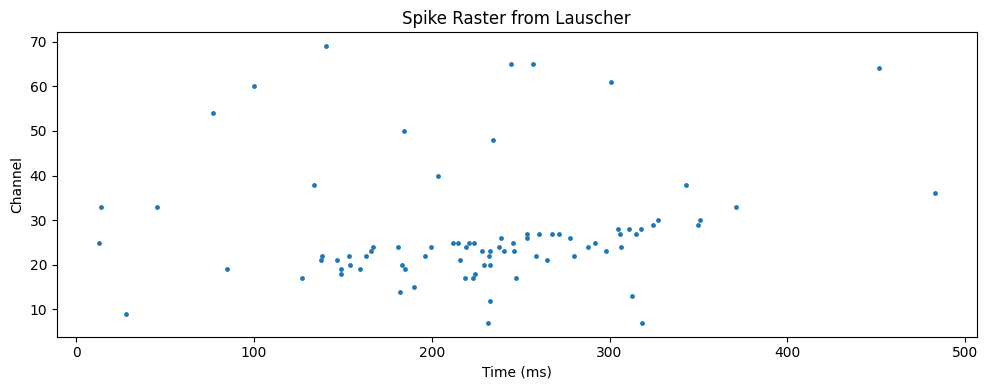

In [82]:

# ============================================================
# 6️⃣ Plot Raster Plot
# ============================================================

plt.figure(figsize=(10, 4))
plt.scatter(times * 1000, channels, s=6)
plt.xlabel("Time (ms)")
plt.ylabel("Channel")
plt.title("Spike Raster from Lauscher")
plt.tight_layout()
plt.show()


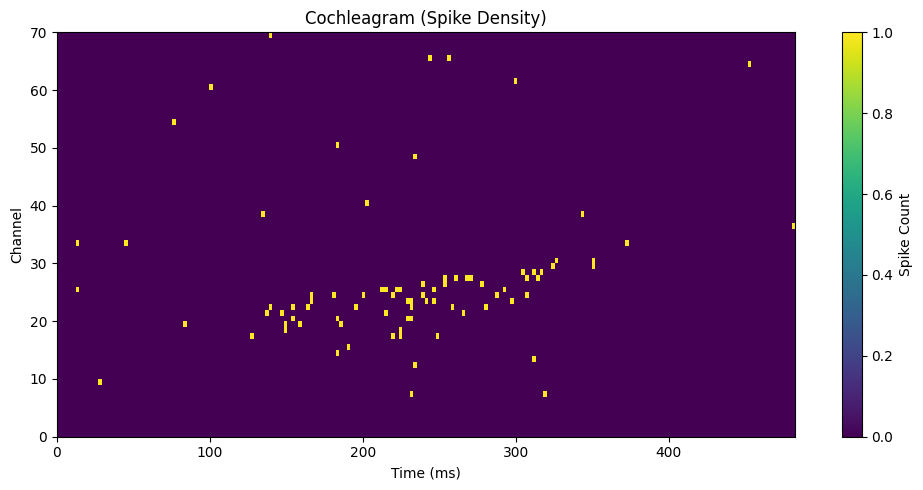

In [83]:

# ============================================================
# 7️⃣ Plot Cochleagram (Spike Density Map)
# ============================================================

time_bins = np.linspace(0, times.max(), 200)

cochleagram = np.zeros((70, len(time_bins)-1))

for ch in range(70):
    ch_times = times[channels == ch]
    hist, _ = np.histogram(ch_times, bins=time_bins)
    cochleagram[ch] = hist

plt.figure(figsize=(10, 5))
plt.imshow(cochleagram,
           aspect='auto',
           origin='lower',
           extent=[0, times.max()*1000, 0, 70])
plt.xlabel("Time (ms)")
plt.ylabel("Channel")
plt.title("Cochleagram (Spike Density)")
plt.colorbar(label="Spike Count")
plt.tight_layout()
plt.show()